In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
from matplotlib.collections import LineCollection
from src.results_paper import *
from src.TimeSeriesAnalysis import *
from src.process_data import process_all_roots, summarize_all_dirs
from IPython.display import clear_output
from matplotlib.lines import Line2D
from matplotlib.ticker import AutoMinorLocator
plt.style.use('properties.mplstyle')

In [7]:
results_folder = "../results/Navigation/3D"
path_sizes = "../results/size_effects/3D"

create_folder(results_folder)
create_folder(path_sizes)

In [3]:
process_all_roots("../Data/bond_percolation", verbose=True, clean_outputs=False)
summarize_all_dirs("../Data/bond_percolation", verbose=True)
clear_output()

In [8]:
df = pd.read_csv("../Data/bond_percolation/all_data.dat", sep=',').sort_values('rho').reset_index(drop=True)
df = df[df['dim']==3]
df

,dim,L,Nt,k,nc,rho,p0,P0,order,N_samples,p_mean,p_err,shortest_path,shortest_path_err,S_perc,S_perc_err
0,3,1024,3000,0.000001,4,0.001000,1.0,1.000000,2,10,0.249459,0.000007,9017.500000,200.162170,2.838609e+07,5.282862e+05
1,3,1024,3000,0.000001,4,0.001000,1.0,1.000000,4,10,0.249544,0.000008,9236.500000,176.047926,2.838491e+07,5.277714e+05
2,3,1024,3000,0.000001,4,0.001000,1.0,1.000000,1,10,0.249340,0.000007,8640.200000,220.007717,2.838504e+07,5.282409e+05
3,3,1024,3000,0.000001,4,0.001000,1.0,1.000000,3,10,0.249516,0.000008,8919.500000,158.944522,2.838602e+07,5.280366e+05
4,3,1024,3000,0.000001,4,0.006005,1.0,0.100000,1,10,0.249410,0.000008,8509.400000,226.308550,2.765863e+07,6.239480e+05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13792,3,128,3000,0.000001,2,0.500000,1.0,0.102584,1,503,0.590917,0.000432,144.393638,0.164707,8.977349e+05,2.667123e+03
13793,3,384,3000,0.000001,2,0.500000,1.0,0.100000,2,76,0.251706,0.000008,1767.736842,8.056824,6.023410e+06,2.545355e+04
13794,3,1024,3000,0.000001,1,1.000000,1.0,0.100000,1,10,0.248962,0.000007,11736.500000,556.178094,3.536131e+07,1.676786e+06
13795,3,512,3000,0.000001,1,1.000000,1.0,0.100000,1,30,0.249579,0.000009,3487.266667,77.043560,1.114699e+07,2.374546e+05


In [20]:
df_s = df[df['nc']==4]['L'].unique()
df_s

array([1024,  512,  384,  256,  192,  128])

In [19]:
L_alvo = [ 512,  256,  128, 192, 1024]
nc = 2

df_f = df[(df["L"].isin(L_alvo)) & (df["nc"] == nc)].copy()

# ajuste o número de casas conforme seu dataset (10–12 costuma bastar)
df_f["rho_key"] = df_f["rho"].round(12)

rhos_comuns = (
    df_f.groupby("rho_key")["L"]
        .nunique()
        .loc[lambda s: s == len(L_alvo)]
        .index
)

df_comum = df_f[df_f["rho_key"].isin(rhos_comuns)].copy()

# se você quer ver os valores "originais" de rho correspondentes:
df_comum["rho"].unique()

with np.printoptions(threshold=np.inf):
    print(df_comum["rho_key"].unique().tolist())
    print(len(df_comum["rho_key"].unique().tolist()))

[0.125]
1


In [15]:
df.head()

,dim,L,Nt,k,nc,rho,p0,P0,order,N_samples,p_mean,p_err,shortest_path,shortest_path_err,S_perc,S_perc_err
0,3,1024,3000,0.000001,4,0.001000,1.0,1.0,1,10,0.249340,0.000007,8640.2,220.007717,28385039.3,528240.943520
1,3,1024,3000,0.000001,4,0.001000,1.0,1.0,2,10,0.249459,0.000007,9017.5,200.162170,28386085.9,528286.233549
2,3,1024,3000,0.000001,4,0.001000,1.0,1.0,3,10,0.249516,0.000008,8919.5,158.944522,28386018.4,528036.591525
3,3,1024,3000,0.000001,4,0.001000,1.0,1.0,4,10,0.249544,0.000008,9236.5,176.047926,28384908.2,527771.393318
4,3,1024,3000,0.000001,4,0.006005,1.0,0.1,2,10,0.249439,0.000008,8692.8,237.853400,27656187.8,622644.031575


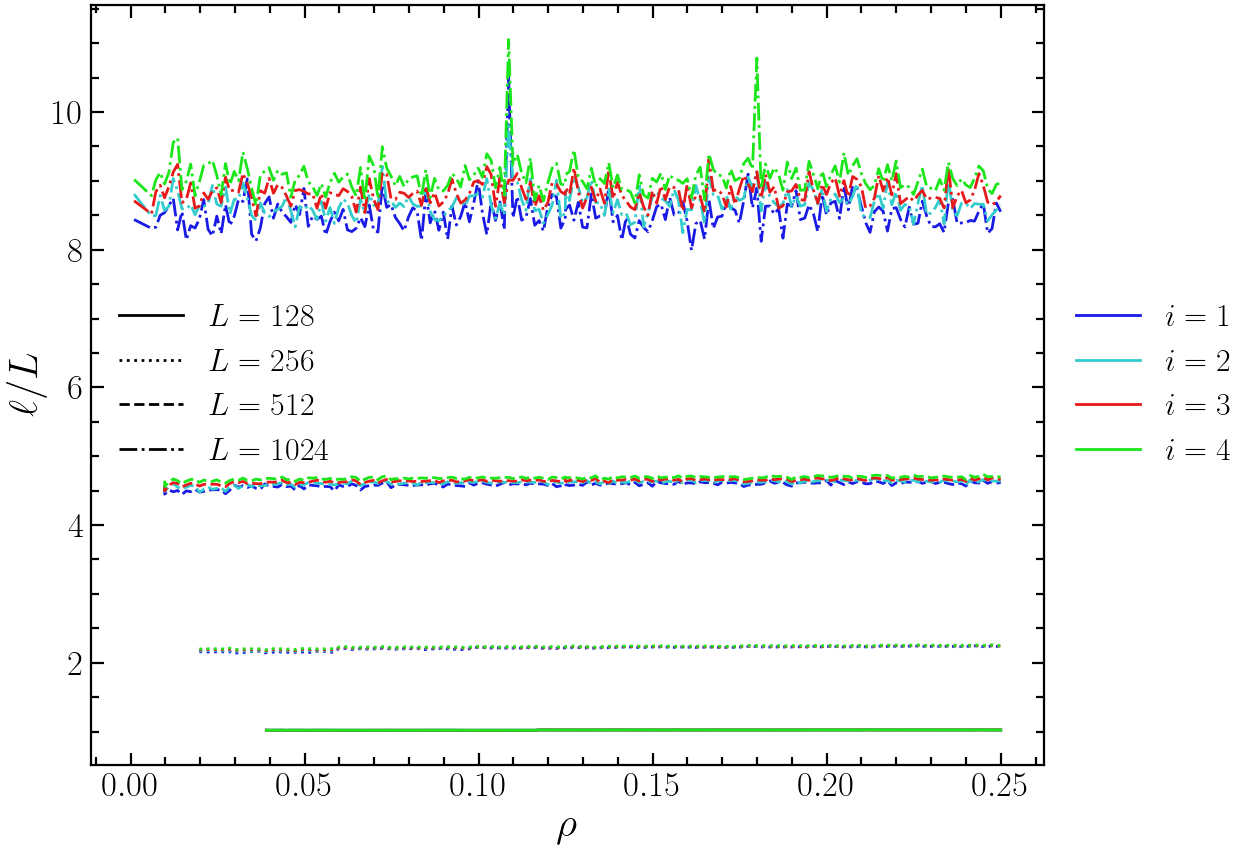

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

L_lst = [128, 256, 512, 1024]
nc = 4
orders = [i for i in range(1, nc+1)]

colors = [
    (0.1, 0.1, 0.9),  # blue
    (0.2, 0.8, 0.8),  # teal
    (0.9, 0.1, 0.1),  # red
    (0.1, 0.9, 0.1),  # green
]
fs_legend_global = 23
fs_legend_local = 23
fs_ticks = 25
fs_labels = 30
lw_data = 2.0

tick_w = 1.6


ls = ['solid', 'dotted', 'dashed', 'dashdot']

fig, ax = plt.subplots(figsize=(13, 9))



# ======================
# Plot
# ======================
for idx, L in enumerate(L_lst):
    for idx_c, ord in enumerate(orders):
        df_sub = df[(df["L"]==L) & (df['nc']==nc) & (df['order']==ord)]
        
        x = np.asarray(df_sub['rho'])
        y = np.asarray(df_sub['shortest_path']/L)
        y_err = np.asarray(df_sub['shortest_path_err']/L)
        
        
        ax.plot(
            df_sub['rho'],
            df_sub['shortest_path']/L,
            ls=ls[idx],
            color=colors[idx_c],
            lw=lw_data
        )

ax.set_ylabel(r"$\ell/L$",fontsize=fs_labels)
ax.set_xlabel(r"$\rho$",fontsize=fs_labels)

# ======================
# Legenda interna → L (linestyle, preto)
# ======================
legend_L = [
    Line2D([0], [0],
           color='black',
           linestyle=ls[i],
           lw=lw_data,
           label=fr"$L={L_lst[i]}$")
    for i in range(len(L_lst))
]

leg1 = ax.legend(
    handles=legend_L,
#    loc='upper left',
    frameon=False,
    fontsize=fs_legend_local
)

# ======================
# Legenda externa → ordem i (cores)
# ======================
legend_i = [
    Line2D([0], [0],
           color=colors[i],
           lw=lw_data,
           label=fr"$i={orders[i]}$")
    for i in range(len(orders))
]

leg2 = ax.legend(
    handles=legend_i,
    bbox_to_anchor=(1.02, 0.5),   # x fora, y central
    loc='center left',
    borderaxespad=0.,
    frameon=False,
    fontsize=fs_legend_global
)

ax.tick_params(axis='both', which='both', width=tick_w, labelsize=fs_ticks)
ax.add_artist(leg1)
for spine in ax.spines.values():
    spine.set_linewidth(tick_w)

plt.tight_layout()
plt.savefig(path_sizes + "/shortest_from_rho.pdf")
plt.show()

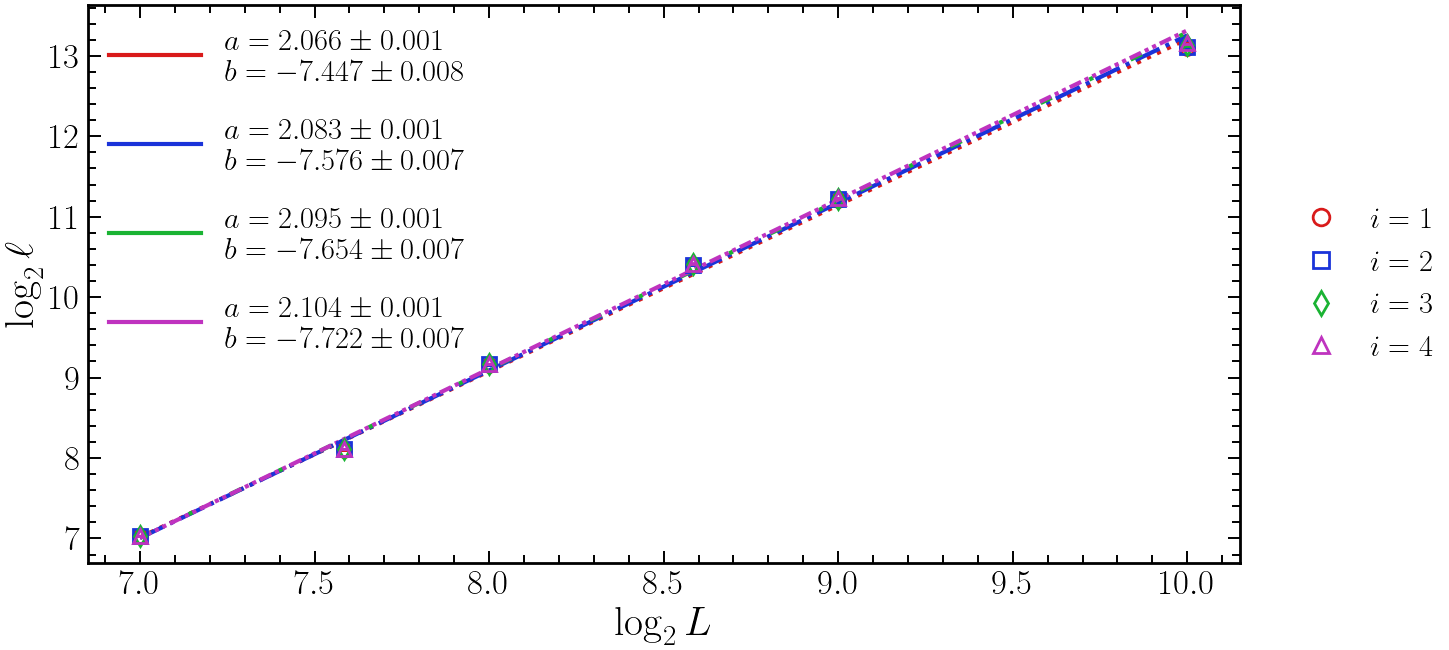

In [69]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.optimize import curve_fit

def log2_with_error(val, err):
    val = np.asarray(val, dtype=float)
    err = np.asarray(err, dtype=float)
    y = np.log2(val)
    y_err = err / (val * np.log(2))
    return y, y_err

def fit_linear_weighted(x, y, y_err):
    def linear(x, a, b):
        return a * x + b
    popt, pcov = curve_fit(linear, x, y, sigma=y_err, absolute_sigma=True)
    a, b = popt
    sigma_a, sigma_b = np.sqrt(np.diag(pcov))
    return a, b, sigma_a, sigma_b

def extract_shortest_path_data(df, L_lst, nc, ord, rho=None):
    if rho is None:
        rho = 1 / nc

    short = []
    short_err = []
    for L in L_lst:
        df_sub = df[
            (df["L"] == L) &
            (df["nc"] == nc) &
            (df["order"] == ord) &
            (df["rho"] == rho)
        ]
        if df_sub.empty:
            raise ValueError(f"Sem dados para L={L}, nc={nc}, ord={ord}, rho={rho}")

        short.append(df_sub["shortest_path"].values[0])
        short_err.append(df_sub["shortest_path_err"].values[0])

    return np.asarray(L_lst, float), np.asarray(short, float), np.asarray(short_err, float)

def plot_all_orders_together_two_legends(
    df, L_lst, nc,
    orders=None, rho=None,
    figsize=(9, 7),
    fs_ticks=25, fs_labels=30,
    fs_leg_out=22, fs_leg_in=22,
    lw_data=0.0,   # marcador-only (como seu exemplo)
    lw_fit=3.0,
    capsize=4
):
    if orders is None:
        orders = [i for i in range(1, nc+1)]
    if rho is None:
        rho = 1 / nc

    # cores (se quiser tudo preto, troque por ['k']*len(orders))
    colors = [
        (0.85, 0.1, 0.1),
        (0.1, 0.2, 0.85),
        (0.1, 0.7, 0.2),
        (0.75, 0.2, 0.75),
    ]

    # símbolos diferentes para cada i (como no seu exemplo 2)
    markers = ['o', 's', 'd', '^']  # círculo, quadrado, losango, triângulo

    fig, ax = plt.subplots(figsize=figsize)

    x = np.log2(np.asarray(L_lst, dtype=float))
    x_fit = np.linspace(x.min(), x.max(), 400)

    # --- handles/labels para as duas legendas ---
    handles_out, labels_out = [], []  # fora: i = ...
    handles_in, labels_in = [], []    # dentro: a,b...

    for idx, ord in enumerate(orders):
        c = colors[idx % len(colors)]
        m = markers[idx % len(markers)]

        L, short, short_err = extract_shortest_path_data(df, L_lst, nc, ord, rho=rho)
        y, y_err = log2_with_error(short, short_err)

        a, b, sigma_a, sigma_b = fit_linear_weighted(x, y, y_err)

        # pontos (marcador vazio com borda colorida, como exemplo)
        ax.errorbar(
            x, y, yerr=y_err,
            fmt=m,
            ms=10,
            mfc='none',
            mec=c,
            mew=2.0,
            ecolor=c,
            elinewidth=1.8,
            capsize=capsize,
            lw=lw_data
        )

        # reta do fit
        ax.plot(x_fit, a*x_fit + b, color=c, lw=lw_fit)

        # -------- legenda fora (somente símbolos + i) --------
        handles_out.append(Line2D([0], [0], marker=m, linestyle='None',
                                  markerfacecolor='none', markeredgecolor=c,
                                  markeredgewidth=2.0, markersize=12))
        labels_out.append(rf"$i= {ord}$")

        # -------- legenda dentro (somente a e b, com a mesma cor da reta) --------
        handles_in.append(Line2D([0], [0], color=c, lw=lw_fit))
        labels_in.append(
            rf"$a={a:.3f}\pm{sigma_a:.3f}$" "\n"
            rf"$b={b:.3f}\pm{sigma_b:.3f}$"
        )

    ax.set_xlabel(r"$\log_2 L$", fontsize=fs_labels)
    ax.set_ylabel(r"$\log_2 \ell$", fontsize=fs_labels)
    ax.tick_params(axis='both', which='major', labelsize=fs_ticks)

    # --- legenda interna: parâmetros (dentro) ---
    leg_in = ax.legend(
        handles_in, labels_in,
        loc="upper left",
        fontsize=fs_leg_in,
        frameon=False,
        handlelength=3.0,
        labelspacing=1.0,
        borderpad=0.2
    )
    ax.add_artist(leg_in)

    # --- legenda externa: i (fora) ---
    ax.legend(
        handles_out, labels_out,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        fontsize=fs_leg_out,
        frameon=False,
        handletextpad=0.6
    )

    fig.tight_layout()
    return fig, ax


# =========================
# USO
# =========================
nc = 4
orders = [i for i in range(1, nc+1)]
L_lst = [128, 192, 256, 384, 512, 1024]
rho = 1/nc

fig, ax = plot_all_orders_together_two_legends(
    df=df, L_lst=L_lst, nc=nc, orders=orders, rho=rho,
    figsize=(15, 7),
    fs_ticks=25, fs_labels=30,
    fs_leg_out=22, fs_leg_in=22,
    lw_fit=3.0
)
plt.savefig(results_folder + "/shortest_versus_L.png")
plt.show()


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def fit_pc_finite_size(
    L,
    pc,
    pc_err=None,
    omega=1.0,
    L_min=None,
    plot=False,
    ax=None
):
    """
    Ajuste: p_c(L) = p_inf + a * L^{-omega}

    Parâmetros
    ----------
    L : array-like
        Tamanhos do sistema.
    pc : array-like
        Valores de p_c(L).
    pc_err : array-like ou None
        Erros associados a p_c. Se None, ajuste não ponderado.
    omega : float
        Expoente desejado.
    L_min : float ou None
        Se definido, usa apenas L >= L_min.
    plot : bool
        Se True, faz o plot do ajuste.
    ax : matplotlib axis ou None
        Eixo onde plotar.

    Retorna
    -------
    dict com parâmetros do ajuste.
    """

    L = np.asarray(L, dtype=float)
    pc = np.asarray(pc, dtype=float)

    if pc_err is not None:
        pc_err = np.asarray(pc_err, dtype=float)

    # corte opcional
    if L_min is not None:
        mask = (L >= L_min)
        L = L[mask]
        pc = pc[mask]
        if pc_err is not None:
            pc_err = pc_err[mask]

    x = L ** (-omega)

    def model(x, p_inf, a):
        return p_inf + a * x

    if pc_err is not None:
        popt, pcov = curve_fit(
            model, x, pc,
            sigma=pc_err,
            absolute_sigma=True
        )
    else:
        popt, pcov = curve_fit(model, x, pc)

    p_inf, a = popt
    sigma_pinf, sigma_a = np.sqrt(np.diag(pcov))

    # chi² reduzido (se houver erro)
    chi2_red = None
    if pc_err is not None:
        residuals = pc - model(x, p_inf, a)
        chi2 = np.sum((residuals / pc_err) ** 2)
        ndof = len(pc) - 2
        if ndof > 0:
            chi2_red = chi2 / ndof

    # Plot opcional
    if plot:
        if ax is None:
            fig, ax = plt.subplots(figsize=(7,6))

        ax.errorbar(
            1/L, pc,
            yerr=pc_err if pc_err is not None else None,
            fmt='o',
            capsize=4
        )

        L_fit = np.linspace(min(L), max(L), 400)
        ax.plot(
            1/L_fit,
            p_inf + a * L_fit**(-omega),
            '-',
            lw=2.5,
            label=rf"$\omega={omega}$" "\n"
                  rf"$p_\infty={p_inf:.6f}\pm{sigma_pinf:.6f}$"
        )

        ax.set_xlabel(r"$1/L$")
        ax.set_ylabel(r"$p_c(L)$")
        ax.legend()
        plt.tight_layout()

    return {
        "omega": omega,
        "p_inf": p_inf,
        "sigma_p_inf": sigma_pinf,
        "a": a,
        "sigma_a": sigma_a,
        "chi2_red": chi2_red
    }

def format_param_parenthesis(value, error):
    """
    Formato: valor(erro)
    Erro com 1 dígito significativo.
    Nunca usa notação científica.
    """

    if error == 0 or np.isnan(error):
        return f"{value}"

    exponent = int(math.floor(math.log10(abs(error))))
    
    # número de casas decimais necessárias
    decimals = -exponent if exponent < 0 else 0

    # erro com 1 dígito significativo
    error_rounded = round(error, decimals)
    value_rounded = round(value, decimals)

    # converte erro para inteiro na casa correta
    error_int = int(round(error_rounded * 10**decimals))

    # formata valor com número fixo de casas
    value_str = f"{value_rounded:.{decimals}f}"

    return f"{value_str}({error_int})"

def format_legend(A, sigma_A, B, sigma_B, nu):

    A_str = format_param_parenthesis(A, sigma_A)
    B_str = format_param_parenthesis(B, sigma_B)

    return (
        rf"$\nu = {nu:.3f}$" + "\n" +
        rf"$A = {A_str}$" + "\n" +
        rf"$B = {B_str}$"
    )
def linear_regression_weighted(x, y, y_err):
    """
    Regressão linear ponderada.

    Modelo: y = A x + B

    Retorna:
    A, B
    sigma_A, sigma_B
    chi2, chi2_red
    R2
    y_fit
    """
    w = 1.0 / (y_err**2)

    S   = np.sum(w)
    Sx  = np.sum(w * x)
    Sy  = np.sum(w * y)
    Sxx = np.sum(w * x * x)
    Sxy = np.sum(w * x * y)

    Delta = S * Sxx - Sx**2

    A = (S * Sxy - Sx * Sy) / Delta
    B = (Sxx * Sy - Sx * Sxy) / Delta

    sigma_A = np.sqrt(S / Delta)
    sigma_B = np.sqrt(Sxx / Delta)

    y_fit = A * x + B

    # χ²
    chi2 = np.sum(w * (y - y_fit)**2)
    dof = len(x) - 2
    chi2_red = chi2 / dof if dof > 0 else np.nan

    # R² ponderado
    y_mean_w = Sy / S
    chi2_tot = np.sum(w * (y - y_mean_w)**2)

    R2 = 1.0 - chi2 / chi2_tot if chi2_tot > 0 else np.nan

    return A, B, sigma_A, sigma_B, chi2, chi2_red, R2, y_fit


In [95]:
df.head()

,dim,L,Nt,k,nc,rho,p0,P0,order,N_samples,p_mean,p_err,shortest_path,shortest_path_err,S_perc,S_perc_err
0,3,1024,3000,0.000001,4,0.001000,1.0,1.0,1,10,0.249340,0.000007,8640.2,220.007717,28385039.3,528240.943520
1,3,1024,3000,0.000001,4,0.001000,1.0,1.0,2,10,0.249459,0.000007,9017.5,200.162170,28386085.9,528286.233549
2,3,1024,3000,0.000001,4,0.001000,1.0,1.0,3,10,0.249516,0.000008,8919.5,158.944522,28386018.4,528036.591525
3,3,1024,3000,0.000001,4,0.001000,1.0,1.0,4,10,0.249544,0.000008,9236.5,176.047926,28384908.2,527771.393318
4,3,1024,3000,0.000001,4,0.006005,1.0,0.1,2,10,0.249439,0.000008,8692.8,237.853400,27656187.8,622644.031575


In [5]:
len(df[(df['L']==128) & (df['dim']==3) &( df['num_colors']==4)]['rho'].unique())
df

,dim,L,Nt,k,nc,rho,p0,P0,order,N_samples,p_mean,p_err,shortest_path,shortest_path_err,S_perc,S_perc_err
0,3,1024,3000,0.000001,4,0.001000,1.0,1.000000,1,10,0.249340,0.000007,8640.200000,220.007717,2.838504e+07,5.282409e+05
1,3,1024,3000,0.000001,4,0.001000,1.0,1.000000,2,10,0.249459,0.000007,9017.500000,200.162170,2.838609e+07,5.282862e+05
2,3,1024,3000,0.000001,4,0.001000,1.0,1.000000,3,10,0.249516,0.000008,8919.500000,158.944522,2.838602e+07,5.280366e+05
3,3,1024,3000,0.000001,4,0.001000,1.0,1.000000,4,10,0.249544,0.000008,9236.500000,176.047926,2.838491e+07,5.277714e+05
4,3,1024,3000,0.000001,4,0.006005,1.0,0.100000,2,10,0.249439,0.000008,8692.800000,237.853400,2.765619e+07,6.226440e+05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13616,3,128,3000,0.000001,2,0.500000,1.0,0.102584,1,503,0.590917,0.000432,144.393638,0.164707,8.977349e+05,2.667123e+03
13617,3,384,3000,0.000001,2,0.500000,1.0,0.100000,2,1,NaN,NaN,1795.000000,0.000000,6.115206e+06,0.000000e+00
13618,3,1024,3000,0.000001,1,1.000000,1.0,0.100000,1,10,0.248962,0.000007,11736.500000,556.178094,3.536131e+07,1.676786e+06
13619,3,512,3000,0.000001,1,1.000000,1.0,0.100000,1,30,0.249579,0.000009,3487.266667,77.043560,1.114699e+07,2.374546e+05


/tmp/ipykernel_22802/3192842828.py:35: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax.plot(l, pc,'o', ms=ms, mew=mew, marker=markers[idx], color=colors[idx], label=f'$i = {ord}$')


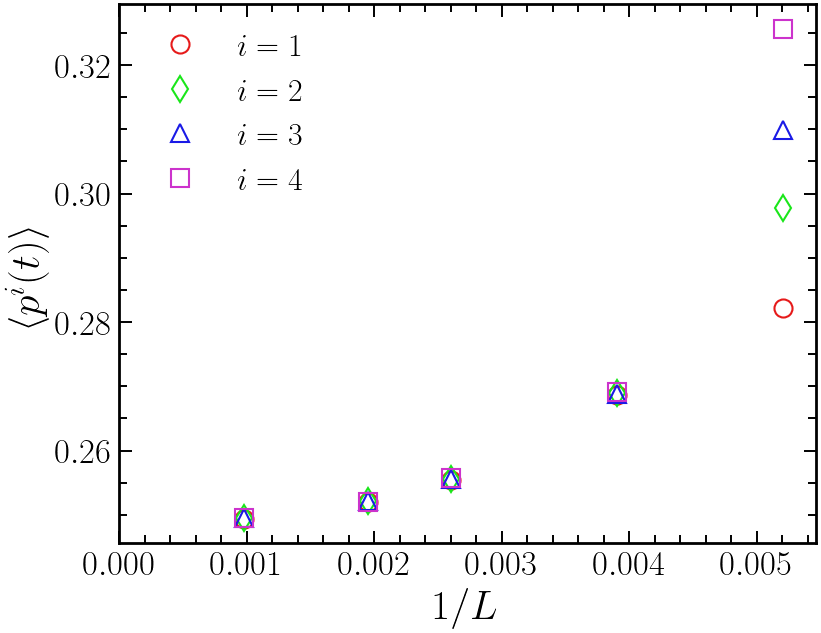

In [14]:
L_lst = [192, 256, 384, 512, 1024]

nc = 4
rho = 1/nc
fs_legend_global = 23
fs_legend_local = 23
fs_ticks = 25
fs_labels = 30
mew = 1.5
ms = 13
tick_w = 1.6
markers = ["o", "d", "^", "s", "D", "v"]
orders = [i for i in range(1, nc+1)]

fig, ax = plt.subplots(figsize=(9, 7))
l = np.asarray([1/i for i in L_lst], float)
data_pi = {"order":[], "L_lst":[], "pc":[], "pc_err":[]}
colors = [(0.9,0.1,0.1),(0.1,0.9,0.1),(0.1,0.1,0.9),(0.8,0.2,0.8)]

for idx, ord in enumerate(orders):
    pc_lst = []
    pc_err_lst = []
    for L in L_lst:
        df_sub = df[(df['L']==L) & (df['nc']==nc) & (df['rho']==rho) & (df['order']==ord)]
        pc_lst.append(df_sub['p_mean'].values[0])
        pc_err_lst.append(df_sub['p_err'].values[0])    
        
    pc = np.asarray(pc_lst, float)
    pc_err = np.asarray(pc_err_lst, float)
    
    data_pi['order'].append(ord)
    data_pi['L_lst'].append(l)
    data_pi['pc'].append(pc)
    data_pi['pc_err'].append(pc_err)
    ax.plot(l, pc,'o', ms=ms, mew=mew, marker=markers[idx], color=colors[idx], label=f'$i = {ord}$') 

df_pi = pd.DataFrame(data=data_pi)

ax.set_xlabel(r"$1/L$",fontsize=fs_labels)
ax.set_ylabel(r"$\langle p^i(t) \rangle$",fontsize=fs_labels)
ax.legend(fontsize=fs_legend_local)
ax.set_xlim([0,max(l)+max(l)*0.05])
ax.tick_params(axis='both', which='major', labelsize=fs_ticks)
plt.savefig(path_sizes + "/L_versus_p.pdf")
plt.show()

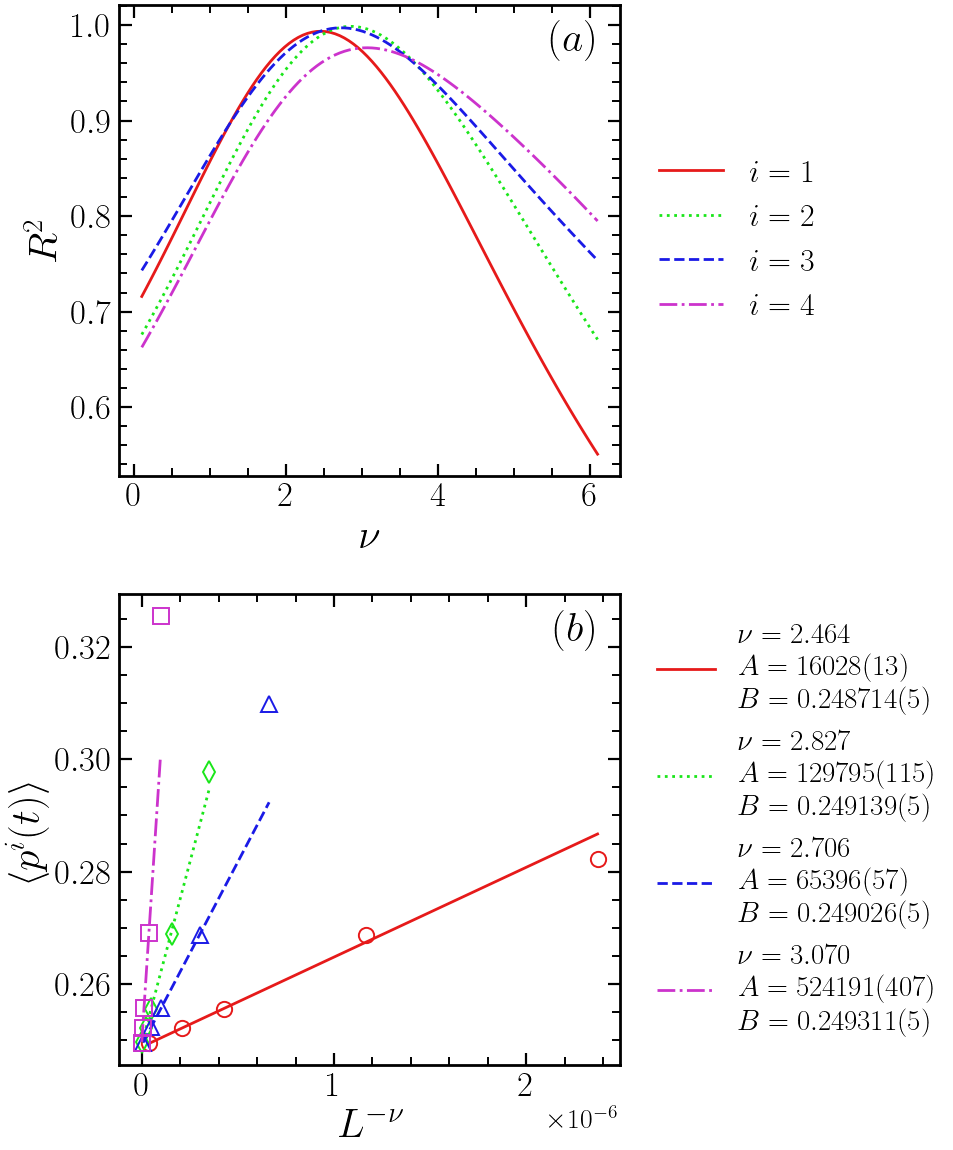

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Espera-se que existam:
# df, df_pi, L_lst, orders, nc, rho
# linear_regression_weighted(x,y,y_err) -> (A,B,sA,sB,chi2,chi2_red,R2,y_fit)
# format_legend(A, sigma_A, B, sigma_B, nu)

nu = np.linspace(0.1, 6.1, 100)

fs_ticks = 25
fs_labels = 30
lw_data = 2.0
tick_w = 1.6
ms_data = 11
mew = 1.4
markers = ["o", "d", "^", "s", "D", "v"]
colors = [(0.9,0.1,0.1),
          (0.1,0.9,0.1),
          (0.1,0.1,0.9),
          (0.8,0.2,0.8)]

# ======================================================
# Figura 2x1
# ======================================================
fig, axes = plt.subplots(2, 1, figsize=(13, 12))
ax_top = axes[0]
ax_bot = axes[1]
labels_fig = ["$(a)$", "$(b)$"]
# ======================================================
# PLOT DE CIMA: R² vs nu (4 curvas)
# ======================================================
data = {"order": [], "A": [], "sigma_A": [], "B": [], "sigma_B": [], "nu": [], "R²": []}

for idx, ord in enumerate(orders):

    pc_lst = []
    pc_err_lst = []
    for L in L_lst:
        df_sub = df[(df['L'] == L) & (df['nc'] == nc) & (df['rho'] == rho) & (df['order'] == ord)]
        pc_lst.append(df_sub['p_mean'].values[0])
        pc_err_lst.append(df_sub['p_err'].values[0])

    pc_lst = np.asarray(pc_lst, float)
    pc_err_lst = np.asarray(pc_err_lst, float)

    for ni in nu:
        x = np.asarray([1 / (L**ni) for L in L_lst], float)
        y = pc_lst
        y_err = pc_err_lst

        parms = linear_regression_weighted(x, y, y_err)
        A, B, sigma_A, sigma_B, R2 = parms[0], parms[1], parms[2], parms[3], parms[6]

        data["order"].append(ord)
        data["nu"].append(ni)
        data["R²"].append(R2)
        data["A"].append(A)
        data["B"].append(B)
        data["sigma_A"].append(sigma_A)
        data["sigma_B"].append(sigma_B)

df_new = pd.DataFrame(data=data)

df_best_per_order = (
    df_new.loc[df_new.groupby("order")["R²"].idxmax()]
          .sort_values("order")
          .reset_index(drop=True)
)

# curvas R²(nu)
for idx, ord in enumerate(orders):
    df_ord = df_new[df_new["order"] == ord]
    ax_top.plot(df_ord["nu"], df_ord["R²"], lw=lw_data, color=colors[idx], label=fr"$i={ord}$")

ax_top.set_xlabel(r"$\nu$", fontsize=fs_labels)
ax_top.set_ylabel(r"$R^2$", fontsize=fs_labels)
ax_top.tick_params(axis='both', which='major', labelsize=fs_ticks, width=tick_w)

# legenda fora (direita), centralizada
leg_top = ax_top.legend(
    bbox_to_anchor=(1.02, 0.5),
    loc='center left',
    frameon=False,
    fontsize=fs_ticks-2
)

# ======================================================
# PLOT DE BAIXO: ajuste com nu ótimo por ordem
# ======================================================
for index in range(nc):

    L_inv = np.asarray(df_pi.iloc[index]["L_lst"], float)  # já é 1/L
    pc = np.asarray(df_pi.iloc[index]["pc"], float)
    pc_err = np.asarray(df_pi.iloc[index]["pc_err"], float)

    A = df_best_per_order.iloc[index]["A"]
    B = df_best_per_order.iloc[index]["B"]
    nu_best = df_best_per_order.iloc[index]["nu"]
    sigma_A = df_best_per_order.iloc[index]["sigma_A"]
    sigma_B = df_best_per_order.iloc[index]["sigma_B"]

    x = L_inv**nu_best
    y_pred = A * x + B

    ax_bot.plot(
        x, pc,
        marker=markers[index],
        linestyle='none',
        color=colors[index],
        ms=ms_data,
        mew=mew,
    )

    x_fit = np.linspace(np.min(x), np.max(x), 200)
    label_text = format_legend(A, sigma_A, B, sigma_B, nu_best)

    ax_bot.plot(
        x_fit, A * x_fit + B,
        color=colors[index],
        lw=2,
        label=label_text
    )
    
    #ax_bot.set_xlim([0, max(x)*1.2])

ax_bot.set_xlabel(r"$L^{-\nu}$", fontsize=fs_labels)
ax_bot.set_ylabel(r"$\langle p^i(t) \rangle$", fontsize=fs_labels)
ax_bot.tick_params(axis='both', which='major', labelsize=fs_ticks, width=tick_w)

ax_top.text(0.96, 0.88, labels_fig[0],
        transform=ax_top.transAxes, ha='right', va='bottom', fontsize=30)

ax_bot.text(0.96, 0.88, labels_fig[1],
        transform=ax_bot.transAxes, ha='right', va='bottom', fontsize=30)

# legenda fora (direita), centralizada
leg_bot = ax_bot.legend(
    bbox_to_anchor=(1.02, 0.5),
    loc='center left',
    frameon=False,
    fontsize=fs_ticks-4
)

# espaço para as legendas do lado
plt.tight_layout(rect=[0, 0, 0.78, 1])
plt.savefig(path_sizes + "/L_nu_pi.pdf")
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

nu = np.linspace(0.1, 6.1, 100)
data = {"A":[], "B":[], "nu":[], "R²":[]}

fs_legend_global = 23
fs_legend_local = 23
fs_ticks = 25
fs_labels = 30
mew = 1.5
ms = 13
lw_data = 2.0
tick_w = 1.6
markers = ["o", "d", "^", "s", "D", "v"]

# ======================================================
# Calcula R² para cada nu
# ======================================================

for ni in nu:
    x = np.asarray([1/i**(ni) for i in L_lst], float)
    y = np.asarray(pc_lst, float)
    y_err = np.asarray(pc_err_lst, float)

    parms = linear_regression_weighted(x, y, y_err)
    A = parms[0]
    B = parms[1]
    R2 = parms[6]

    data['nu'].append(ni)
    data['R²'].append(R2)
    data['A'].append(A)
    data['B'].append(B)

df_new = pd.DataFrame(data=data)
row_max = df_new.loc[df_new["R²"].idxmax()]

print(row_max)

# ======================================================
# Figura com dois subplots
# ======================================================

fig, axes = plt.subplots(2, 1, figsize=(9, 14))

# ======================
# PLOT 1 — R² vs nu
# ======================

axes[0].plot(data['nu'], data['R²'], lw=lw_data)
axes[0].set_xlabel(r"$\nu$", fontsize=fs_labels)
axes[0].set_ylabel(r"$R^2$", fontsize=fs_labels)
axes[0].tick_params(axis='both', which='major', labelsize=fs_ticks, width=tick_w)

# ======================
# PLOT 2 — Ajuste com nu ótimo
# ======================

A = row_max["A"]
B = row_max["B"]
nu_best = row_max["nu"]

x_mod = np.asarray([1/i**(nu_best) for i in L_lst])
y_pred = A * x_mod + B

axes[1].errorbar(
    [1/i**(nu_best) for i in L_lst],
    pc_lst,
    yerr=pc_err_lst,
    fmt='o',
    ms=ms,
    mew=mew,
    capsize=5
)

axes[1].plot(x_mod, y_pred, ls='solid', lw=lw_data)

axes[1].set_xlabel(r"$1/L^{\nu}$", fontsize=fs_labels)
axes[1].set_ylabel(r"$p_c(L)$", fontsize=fs_labels)
axes[1].tick_params(axis='both', which='major', labelsize=fs_ticks, width=tick_w)

plt.tight_layout()
plt.show()